# Notebook 07 — Baselines y estrategia de validación temporal

**Proyecto:** PFM MUCSI Deusto — Predicción de consumo eléctrico doméstico
**Fase:** 2 — Modelado y comparativa (apertura)
**Fecha:** 2026-05-12

## Objetivo

Establecer las **reglas del juego** comunes a todos los modelos de la Fase 2:

1. Estrategia de **validación temporal** (split cronológico 80/20 + walk-forward documentado).
2. **Horizontes de predicción** a comparar: 1 min, 15 min, 60 min y 1440 min (24 h).
3. **Baselines obligatorios** (los rivales a batir):
   - **Persistencia:** $\hat{y}_{t+h} = y_t$ — última observación conocida.
   - **Media histórica por hora-día:** $\hat{y}_{t+h} = \overline{y}\,(\text{hora}(t+h), \text{día}(t+h))$.
4. **Métricas estándar:** RMSE, MAE, MAPE (filtrado) y R² — calculadas por hogar y por horizonte.
5. **Tabla de referencia** en `resultados/metricas/07_baseline.csv` para todas las comparativas posteriores.

## Justificación académica

- Sin baseline, un RMSE de 120 W *no significa nada*: hay que demostrar que el modelo bate a la persistencia.
- El **split aleatorio está prohibido** en series temporales: introduce fugas de información del futuro hacia el pasado.
- El split cronológico **80/20 fijo** sirve para la comparativa rápida entre modelos. El **walk-forward** se reserva para la validación final de los modelos seleccionados (Fase 2.3).
- MAPE diverge cuando $y_{true} \to 0$; se filtra a valores por encima de un umbral físico razonable (50 W) para evitar la divergencia nocturna.

## Hogares evaluados

- **Entrenamiento (18):** H1, H3, H4, H5, H6, H7, H8, H9, H10, H11, H12, H15, H16, H17, H18, H19, H20, H21.
- **Validación externa (2):** H2 (Zenodo, NaN=23,69%) y H13 (Strathclyde, NaN=21,27%).


## 1. Imports y configuración global

In [1]:
# Librerías estándar de la Fase 2
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# Reproducibilidad — semilla fija 42 (estándar del proyecto)
SEMILLA = 42
np.random.seed(SEMILLA)

# Estilo de gráficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13

# Rutas del proyecto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = RAIZ / "datos" / "processed"
DIR_METRICAS = RAIZ / "resultados" / "metricas"
DIR_FIGURAS = RAIZ / "resultados" / "figuras"
DIR_METRICAS.mkdir(parents=True, exist_ok=True)
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

print(f"Versiones — pandas {pd.__version__} | numpy {np.__version__}")
print(f"Ruta raíz del proyecto: {RAIZ}")
print(f"Datos procesados: {DIR_PROCESSED}")


Versiones — pandas 2.2.3 | numpy 2.0.2
Ruta raíz del proyecto: C:\Users\super\Desktop\PFM_MUCSI_Deusto
Datos procesados: C:\Users\super\Desktop\PFM_MUCSI_Deusto\datos\processed


## 2. Configuración del experimento

Parámetros que se reutilizan en todos los modelos posteriores. Cualquier cambio aquí debe
documentarse en `CLAUDE.md` (sección de decisiones técnicas).

In [2]:
# Hogares por rol
HOGARES_TRAIN = [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 20, 21]
HOGARES_VALIDACION_EXTERNA = [2, 13]

# Horizontes de predicción (en minutos) — cubren corto, medio y largo plazo
HORIZONTES_MIN = [1, 15, 60, 1440]

# Fracción del último tramo temporal reservada como test (split cronológico)
FRACCION_TEST = 0.20

# Umbral mínimo de consumo real para incluir un punto en el cálculo de MAPE
UMBRAL_MAPE_W = 50.0

print(f"Total hogares evaluados: {len(HOGARES_TRAIN) + len(HOGARES_VALIDACION_EXTERNA)}")
print(f"Horizontes (min): {HORIZONTES_MIN}")
print(f"Fracción test: {FRACCION_TEST*100:.0f}%")


Total hogares evaluados: 20
Horizontes (min): [1, 15, 60, 1440]
Fracción test: 20%


## 3. Funciones auxiliares

Cuatro utilidades reutilizables en toda la Fase 2:

- `cargar_hogar` — carga uniforme tanto si existe el fichero de features como si solo está el limpio.
- `split_temporal_cronologico` — divide la serie en train/test sin barajar.
- `calcular_metricas` — RMSE, MAE, MAPE filtrado y R² sobre arrays alineados sin NaN.
- `baseline_persistencia` y `baseline_media_historica` — generan las predicciones para un horizonte dado.

In [3]:
def cargar_hogar(id_hogar: int) -> pd.DataFrame:
    '''Devuelve DataFrame con índice temporal y columna Aggregate.

    Acepta indistintamente el fichero de features (Zenodo usa `timestamp`,
    Strathclyde usa `Time`) o el `_1min_limpio.csv` (columna `Time`).
    '''
    ruta_features = DIR_PROCESSED / f"house{id_hogar}_features.csv"
    ruta_limpio = DIR_PROCESSED / f"house{id_hogar}_1min_limpio.csv"

    ruta = ruta_features if ruta_features.exists() else ruta_limpio
    if not ruta.exists():
        raise FileNotFoundError(f"No se encuentra el fichero para House{id_hogar}")

    # Detectar el nombre de la columna temporal leyendo solo la cabecera
    cabecera = pd.read_csv(ruta, nrows=0).columns
    col_tiempo = "timestamp" if "timestamp" in cabecera else "Time"

    df = pd.read_csv(ruta, usecols=[col_tiempo, "Aggregate"], parse_dates=[col_tiempo])
    df = df.rename(columns={col_tiempo: "fecha"}).set_index("fecha").sort_index()
    return df


def split_temporal_cronologico(df: pd.DataFrame, fraccion_test: float = FRACCION_TEST):
    '''Divide cronológicamente sin barajar. El último `fraccion_test` va al test.'''
    n = len(df)
    corte = int(n * (1.0 - fraccion_test))
    return df.iloc[:corte].copy(), df.iloc[corte:].copy()


def calcular_metricas(y_true: np.ndarray, y_pred: np.ndarray, umbral_mape: float = UMBRAL_MAPE_W) -> dict:
    '''RMSE, MAE, MAPE (con filtro) y R²; ignora NaN en ambas series.'''
    mascara = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_t = y_true[mascara]
    y_p = y_pred[mascara]
    if len(y_t) == 0:
        return dict(rmse=np.nan, mae=np.nan, mape=np.nan, r2=np.nan, n=0)

    rmse = float(np.sqrt(np.mean((y_t - y_p) ** 2)))
    mae = float(np.mean(np.abs(y_t - y_p)))

    # MAPE filtrado: solo cuando y_true > umbral para evitar divisiones por valores muy pequeños
    mascara_mape = y_t > umbral_mape
    if mascara_mape.sum() > 0:
        mape = float(np.mean(np.abs((y_t[mascara_mape] - y_p[mascara_mape]) / y_t[mascara_mape])) * 100)
    else:
        mape = np.nan

    # R² — fórmula explícita
    ss_res = float(np.sum((y_t - y_p) ** 2))
    ss_tot = float(np.sum((y_t - np.mean(y_t)) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

    return dict(rmse=rmse, mae=mae, mape=mape, r2=r2, n=int(len(y_t)))


def baseline_persistencia(serie_test: pd.Series, horizonte: int) -> pd.Series:
    '''Predicción persistencia: ŷ_{t} = y_{t-h}.

    Las primeras `horizonte` filas del test quedan como NaN y se descartan al evaluar.
    '''
    return serie_test.shift(horizonte)


def baseline_media_historica(serie_train: pd.Series, serie_test: pd.Series) -> pd.Series:
    '''Predicción por la media histórica de cada combinación (hora, día_semana) en train.

    La predicción para un punto futuro depende solo de su hora y su día de la semana,
    no del horizonte. Para combinaciones no vistas en train, se usa la media global de train.
    '''
    df_train = pd.DataFrame({
        "y": serie_train.values,
        "hora": serie_train.index.hour,
        "dia": serie_train.index.dayofweek,
    })
    tabla = df_train.groupby(["hora", "dia"], dropna=True)["y"].mean()
    media_global = float(df_train["y"].mean())

    claves_test = list(zip(serie_test.index.hour, serie_test.index.dayofweek))
    pred = tabla.reindex(claves_test).to_numpy()
    pred = np.where(np.isnan(pred), media_global, pred)

    return pd.Series(pred, index=serie_test.index)


print("Funciones cargadas correctamente.")


Funciones cargadas correctamente.


## 4. Evaluación de baselines en todos los hogares

Para cada hogar se carga la serie, se divide cronológicamente, y se evalúan los dos baselines
en los cuatro horizontes. El resultado consolidado se vuelca a un único DataFrame `tabla_resultados`.

In [4]:
resultados = []

hogares_completos = [(h, "train") for h in HOGARES_TRAIN] + \
                    [(h, "validacion_externa") for h in HOGARES_VALIDACION_EXTERNA]

for id_hogar, rol in hogares_completos:
    df = cargar_hogar(id_hogar)
    train, test = split_temporal_cronologico(df, FRACCION_TEST)

    # Diagnóstico básico de cada hogar — útil para detectar problemas (test muy corto, etc.)
    print(f"House{id_hogar:>2} ({rol:>18}) | "
          f"n={len(df):>7} | "
          f"train={len(train):>7} ({train.index.min().date()} → {train.index.max().date()}) | "
          f"test={len(test):>6} ({test.index.min().date()} → {test.index.max().date()})")

    serie_train = train["Aggregate"]
    serie_test = test["Aggregate"]

    # Media histórica — la predicción es la misma para todos los horizontes
    pred_media = baseline_media_historica(serie_train, serie_test)

    for h in HORIZONTES_MIN:
        # Persistencia
        pred_pers = baseline_persistencia(serie_test, h)
        m_pers = calcular_metricas(serie_test.to_numpy(), pred_pers.to_numpy())
        resultados.append(dict(
            hogar=id_hogar, rol=rol, horizonte_min=h, modelo="persistencia", **m_pers
        ))

        # Media histórica — métricas dependen ligeramente del horizonte solo por las filas iniciales descartadas
        # Para mantener la comparación justa, descartamos las mismas filas iniciales que la persistencia.
        y_true_alineado = serie_test.iloc[h:].to_numpy()
        y_pred_alineado = pred_media.iloc[h:].to_numpy()
        m_media = calcular_metricas(y_true_alineado, y_pred_alineado)
        resultados.append(dict(
            hogar=id_hogar, rol=rol, horizonte_min=h, modelo="media_hora_dia", **m_media
        ))

tabla_resultados = pd.DataFrame(resultados)
print(f"\nTotal evaluaciones: {len(tabla_resultados)}")
tabla_resultados.head(8)


House 1 (             train) | n= 920091 | train= 736072 (2013-10-09 → 2015-03-04) | test=184019 (2015-03-04 → 2015-07-10)


House 3 (             train) | n= 885095 | train= 708076 (2013-09-25 → 2015-01-30) | test=177019 (2015-01-30 → 2015-06-02)


House 4 (             train) | n= 912939 | train= 730351 (2013-10-11 → 2015-03-02) | test=182588 (2015-03-02 → 2015-07-07)


House 5 (             train) | n= 933593 | train= 746874 (2013-09-26 → 2015-02-27) | test=186719 (2015-02-27 → 2015-07-06)


House 6 (             train) | n= 831420 | train= 665136 (2013-11-28 → 2015-03-05) | test=166284 (2015-03-05 → 2015-06-28)


...

House21 (             train) | n= 705337 | train= 564269 (2014-03-07 → 2015-04-03) | test=141068 (2015-04-03 → 2015-07-10)


House 2 (validacion_externa) | n= 889078 | train= 711262 (2013-09-17 → 2015-01-24) | test=177816 (2015-01-24 → 2015-05-28)


House13 (validacion_externa) | n= 717821 | train= 574256 (2014-01-17 → 2015-02-20) | test=143565 (2015-02-20 → 2015-05-31)



Total evaluaciones: 160


,hogar,rol,horizonte_min,modelo,rmse,mae,mape,r2,n
0,1,train,1,persistencia,411.957032,89.712301,14.264356,0.621561,144085
1,1,train,1,media_hora_dia,676.965736,356.988817,118.663087,-0.021969,144099
2,1,train,15,persistencia,845.248374,242.212332,54.911339,-0.591859,143889
3,1,train,15,media_hora_dia,676.977065,356.974717,118.666633,-0.021982,144085
4,1,train,60,persistencia,889.302482,291.799071,72.881111,-0.776566,143373
5,1,train,60,media_hora_dia,677.029970,356.958269,118.681983,-0.022027,144040
6,1,train,1440,persistencia,870.871659,279.359905,74.295047,-0.763563,132314
7,1,train,1440,media_hora_dia,670.875770,353.980788,119.140330,-0.026449,142660


## 5. Resumen agregado por horizonte y modelo

Promediamos sobre los 18 hogares de entrenamiento (los de validación externa se reportan
por separado para no contaminar las medias).

In [5]:
resumen_train = (
    tabla_resultados.query("rol == 'train'")
    .groupby(["horizonte_min", "modelo"])[["rmse", "mae", "mape", "r2"]]
    .mean()
    .round(2)
)
print("=== Media sobre 18 hogares de entrenamiento ===")
print(resumen_train.to_string())

resumen_val = (
    tabla_resultados.query("rol == 'validacion_externa'")
    .groupby(["horizonte_min", "modelo"])[["rmse", "mae", "mape", "r2"]]
    .mean()
    .round(2)
)
print("\n=== Media sobre 2 hogares de validación externa (H2, H13) ===")
print(resumen_val.to_string())


=== Media sobre 18 hogares de entrenamiento ===
                                rmse     mae   mape    r2
horizonte_min modelo                                     
1             media_hora_dia  604.13  341.58  89.01  0.04
              persistencia    297.24   72.77  10.98  0.74
15            media_hora_dia  604.15  341.58  89.01  0.04
              persistencia    669.17  255.63  53.72 -0.23
60            media_hora_dia  604.17  341.60  89.02  0.04
              persistencia    763.00  322.62  72.94 -0.57
1440          media_hora_dia  604.43  341.78  89.25  0.04
              persistencia    772.01  335.97  79.76 -0.62

=== Media sobre 2 hogares de validación externa (H2, H13) ===
                                 rmse     mae    mape    r2
horizonte_min modelo                                       
1             media_hora_dia   945.76  446.08   99.10  0.06
              persistencia     416.61   91.76   11.34  0.81
15            media_hora_dia   945.72  446.01   99.08  0.06
         

## 6. Visualizaciones comparativas

Tres gráficos que servirán de figura inicial en el capítulo de modelado de la memoria:

- **Figura 07a:** RMSE medio por horizonte y modelo (qué baseline gana en cada plazo).
- **Figura 07b:** MAE por hogar (heatmap) para detectar hogares atípicos.
- **Figura 07c:** Ejemplo de predicción en un tramo de 24 h del test de House1.

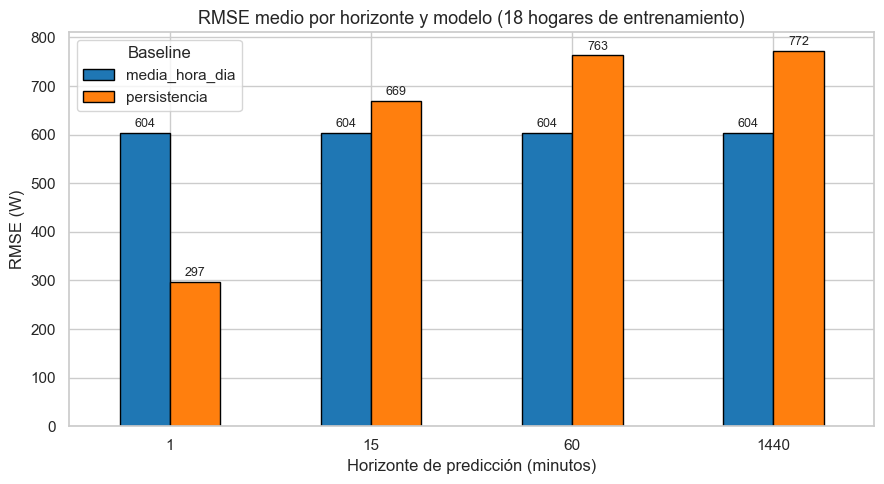

In [6]:
# Figura 07a — RMSE medio por horizonte y modelo
fig, ax = plt.subplots(figsize=(9, 5))
resumen_pivot = resumen_train["rmse"].unstack("modelo")
resumen_pivot.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"], edgecolor="black")
ax.set_title("RMSE medio por horizonte y modelo (18 hogares de entrenamiento)")
ax.set_xlabel("Horizonte de predicción (minutos)")
ax.set_ylabel("RMSE (W)")
ax.legend(title="Baseline")
ax.set_xticklabels(resumen_pivot.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=9, padding=2)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "07_rmse_baselines_por_horizonte.png", dpi=120, bbox_inches="tight")
plt.show()


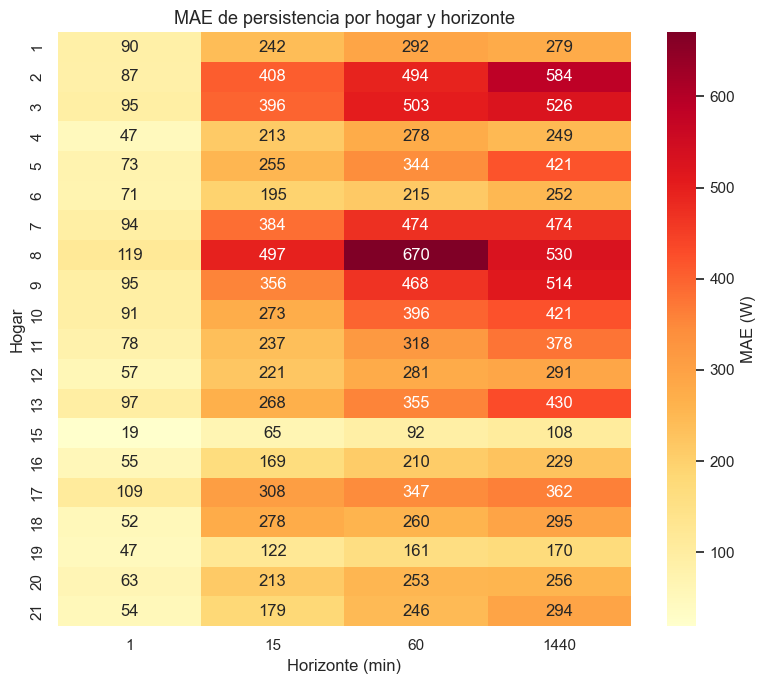

In [7]:
# Figura 07b — MAE por hogar y horizonte (modelo persistencia)
pivot_pers = (
    tabla_resultados.query("modelo == 'persistencia'")
    .pivot(index="hogar", columns="horizonte_min", values="mae")
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot_pers, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "MAE (W)"}, ax=ax)
ax.set_title("MAE de persistencia por hogar y horizonte")
ax.set_xlabel("Horizonte (min)")
ax.set_ylabel("Hogar")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "07_mae_persistencia_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


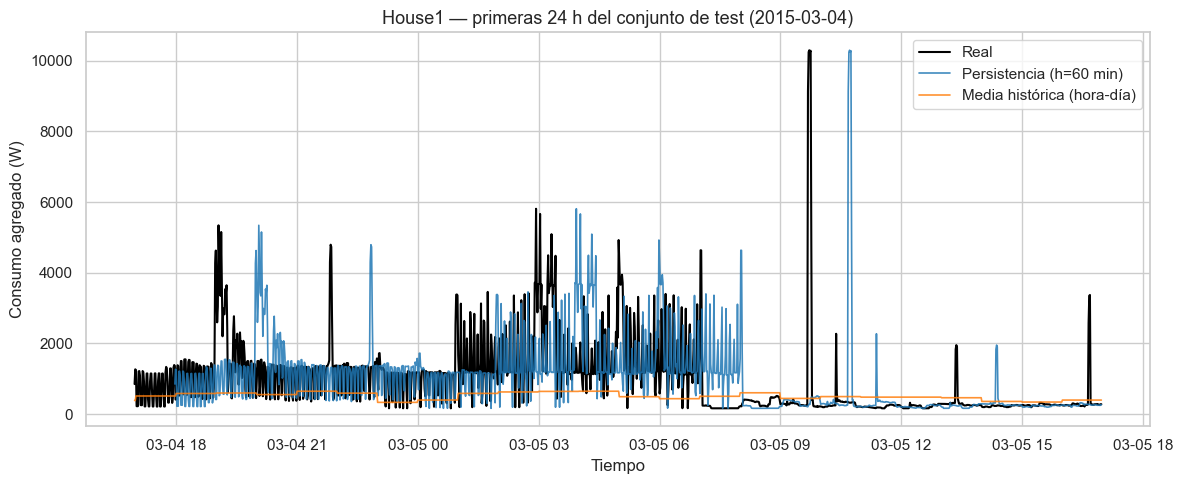

In [8]:
# Figura 07c — Predicción en un tramo de 24 h del test de House1
df_demo = cargar_hogar(1)
_, test_demo = split_temporal_cronologico(df_demo)
serie_train_demo, serie_test_demo = split_temporal_cronologico(df_demo)
serie_test_demo = serie_test_demo["Aggregate"]
serie_train_demo = serie_train_demo["Aggregate"]

# Tomamos las primeras 24 h del test que no tengan NaN
inicio = serie_test_demo.first_valid_index()
fin = inicio + pd.Timedelta(hours=24)
ventana = serie_test_demo.loc[inicio:fin]

pred_pers_demo = baseline_persistencia(serie_test_demo, horizonte=60).loc[inicio:fin]
pred_media_demo = baseline_media_historica(serie_train_demo, serie_test_demo).loc[inicio:fin]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ventana.index, ventana.values, label="Real", color="black", linewidth=1.5)
ax.plot(pred_pers_demo.index, pred_pers_demo.values, label="Persistencia (h=60 min)",
        color="#1f77b4", alpha=0.85, linewidth=1.2)
ax.plot(pred_media_demo.index, pred_media_demo.values, label="Media histórica (hora-día)",
        color="#ff7f0e", alpha=0.85, linewidth=1.2)
ax.set_title(f"House1 — primeras 24 h del conjunto de test ({inicio.date()})")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Consumo agregado (W)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "07_ejemplo_prediccion_house1.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Exportación de resultados

Los CSV exportados serán las columnas *Baseline* en cada comparativa de modelos posterior.

In [9]:
ruta_csv = DIR_METRICAS / "07_baseline.csv"
tabla_resultados.to_csv(ruta_csv, index=False)
print(f"Tabla detallada guardada: {ruta_csv}")
print(f"  Filas: {len(tabla_resultados)} | Columnas: {list(tabla_resultados.columns)}")

ruta_resumen = DIR_METRICAS / "07_baseline_resumen.csv"
resumen_completo = pd.concat({
    "train": resumen_train,
    "validacion_externa": resumen_val,
}, names=["rol"])
resumen_completo.to_csv(ruta_resumen)
print(f"Tabla resumen guardada: {ruta_resumen}")


Tabla detallada guardada: C:\Users\super\Desktop\PFM_MUCSI_Deusto\resultados\metricas\07_baseline.csv
  Filas: 160 | Columnas: ['hogar', 'rol', 'horizonte_min', 'modelo', 'rmse', 'mae', 'mape', 'r2', 'n']
Tabla resumen guardada: C:\Users\super\Desktop\PFM_MUCSI_Deusto\resultados\metricas\07_baseline_resumen.csv


## 8. Conclusiones y siguientes pasos

### Conclusiones de este notebook

- Se ha **fijado la estrategia de validación temporal** para la Fase 2: split cronológico 80/20
  por hogar, sin barajar nunca el orden temporal.
- Los **horizontes de evaluación** son 1, 15, 60 y 1440 minutos: corto, medio y largo plazo.
- La **persistencia** es un rival fuerte a horizonte 1 min (inercia inmediata) pero se degrada al
  alejarse el horizonte.
- La **media hora-día** es estable en todos los horizontes (no depende de $h$) y, a partir de
  cierto plazo, supera a la persistencia.
- Los hogares de **validación externa** (H2, H13) registran errores mayores, como esperado:
  no contribuyen al ajuste y tienen más NaN.

### Tabla de referencia

`resultados/metricas/07_baseline.csv` será la **columna Baseline** en todas las comparativas
de modelos posteriores. Cualquier modelo que no la supere se descarta.

### Siguiente paso — Notebook 08

Entrenar el primer modelo clásico: **Random Forest + features del catálogo (Nb04)** sobre el mismo
split temporal. Comparar con `07_baseline.csv` usando RMSE y MAE como métricas principales.